In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [4]:
X

array([[  5.00434868,  -1.68927397],
       [  4.33854534,  -1.9595391 ],
       [  5.21529163,  -3.80326442],
       ...,
       [ -4.66459762,  -8.18255474],
       [ -6.67722733, -10.69124567],
       [ -7.93347576,  -7.79433807]])

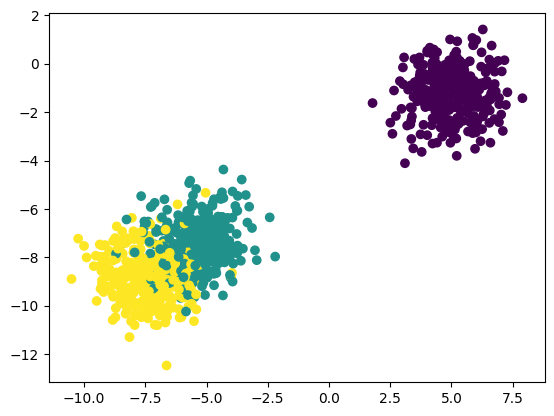

In [5]:
plt.scatter(X[:,0], X[:,1], c=y)

### Standardization

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [8]:
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans

In [10]:
## Elbow method to select K value

wcss = []
for k in range(1, 11):
        kmeans= KMeans(n_clusters=k, init='k-means++')
        kmeans.fit(X_scaled_train)
        wcss.append(kmeans.inertia_)

In [11]:
wcss

[1340.0000000000007,
 114.85152423509584,
 67.05281601639757,
 55.970231472562844,
 52.84410707554892,
 36.704796023126164,
 32.97389045949461,
 29.754626907942693,
 26.953889635692335,
 26.101926414189805]

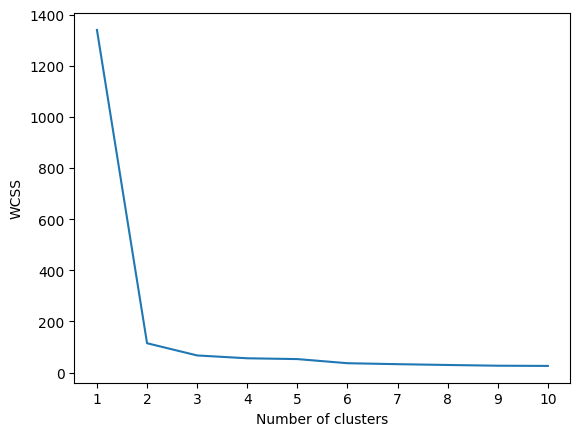

In [12]:
## plot elbow curve
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3, init='k-means++')
kmeans.fit_predict(X_scaled_train)

array([2, 0, 2, 1, 0, 2, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 0, 1, 0, 0, 0, 0,
       2, 2, 1, 0, 1, 1, 0, 1, 2, 0, 1, 0, 0, 1, 2, 1, 2, 2, 2, 0, 1, 0,
       2, 2, 1, 1, 1, 0, 0, 2, 1, 2, 2, 0, 2, 1, 2, 0, 0, 0, 1, 1, 0, 2,
       0, 2, 0, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0, 0, 1,
       2, 2, 2, 0, 1, 0, 2, 2, 0, 1, 0, 0, 1, 2, 2, 1, 2, 1, 0, 0, 1, 1,
       0, 2, 0, 1, 1, 1, 0, 0, 0, 2, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 2, 2,
       0, 0, 1, 0, 0, 0, 1, 2, 1, 1, 1, 2, 1, 2, 0, 2, 1, 0, 2, 0, 1, 2,
       1, 1, 1, 0, 2, 2, 1, 1, 1, 1, 1, 0, 0, 2, 1, 2, 2, 0, 2, 2, 1, 2,
       0, 2, 1, 0, 1, 1, 1, 1, 0, 2, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 0, 2, 2, 1, 2, 1, 0, 1, 2, 2, 2, 1, 2, 1, 2, 1, 1, 0, 1, 1,
       2, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 0, 1, 0, 0, 2, 1, 1, 1,
       2, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 2, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1,
       0, 0, 1, 1, 1, 0, 1, 2, 0, 1, 0, 2, 1, 2, 1, 2, 1, 0, 2, 0, 2, 1,
       2, 2, 2, 0, 0, 2, 0, 1, 1, 1, 1, 2, 0, 2, 0,

In [14]:
ypred = kmeans.predict(X_scaled_test)

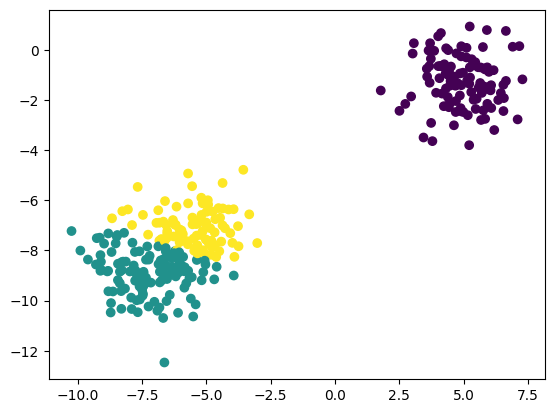

In [15]:
plt.scatter(X_test[:,0], X_test[:,1], c=ypred)

### Validating the k value
#### 1. Kneelocator
#### 2. Silhoutee scoring

In [16]:
### Kneelocator
!pip install kneed

In [17]:
from kneed import KneeLocator
kl = KneeLocator(range(1, 11), wcss,curve='convex', direction='decreasing' )

In [18]:
kl.elbow ## it is gives the value of k

2

In [20]:
## Silhoutte score
from sklearn.metrics import silhouette_score
silhouette_coefficients = []
for k in range(2, 11):
        kmeans= KMeans(n_clusters=k, init='k-means++')
        kmeans.fit(X_scaled_train)
        score = silhouette_score(X_scaled_train, kmeans.labels_)
        silhouette_coefficients.append(score)

In [21]:
silhouette_coefficients

[0.8197540004085359,
 0.57304602178646,
 0.5093683355640631,
 0.5223813171307422,
 0.4909491021320493,
 0.35328191290001354,
 0.3330792990641685,
 0.34695096330815356,
 0.32082713614473124]

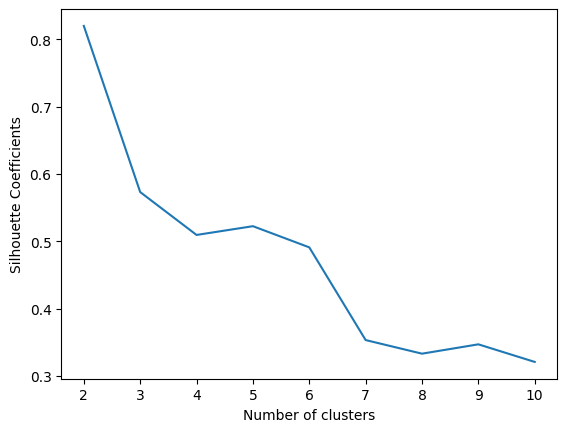

In [23]:
## plot elbow curve
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficients')
plt.show()